In [1]:
#관련 라이브러리 import
from datasets import load_dataset
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

In [2]:
#신발 브랜드 분류용 이미지 데이터 로드
dataset = load_dataset("beans", split='train[:500]')
dataset

Dataset({
    features: ['image_file_path', 'image', 'labels'],
    num_rows: 500
})

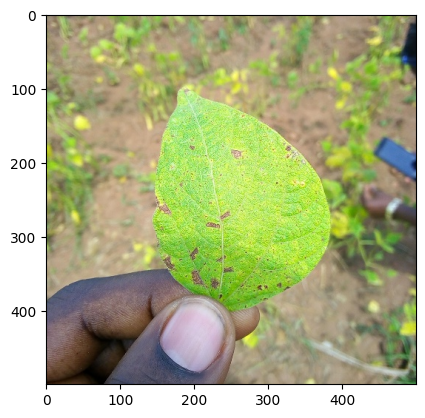

In [3]:
query_image = dataset[44]['image']
plt.imshow(query_image)
plt.show()

In [4]:
type(query_image)

PIL.JpegImagePlugin.JpegImageFile

사진 파일을 그대로 쓰진 않을 것이기 때문에 변환하는 작업이 필요함
- 추후 계산이 가능한 형태인 넘파이로 변환

In [5]:
query_image = np.array(query_image)

In [6]:
query_image.shape

(500, 500, 3)

500 x 500을 (1, 250000) 형태로 변환시켜야함

In [7]:
img_vector = query_image.reshape(1, -1, 3)
img_vector.shape

(1, 250000, 3)

In [8]:
#변환된 벡터로부터 각 채널별(RGB) 벡터 추출
red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]

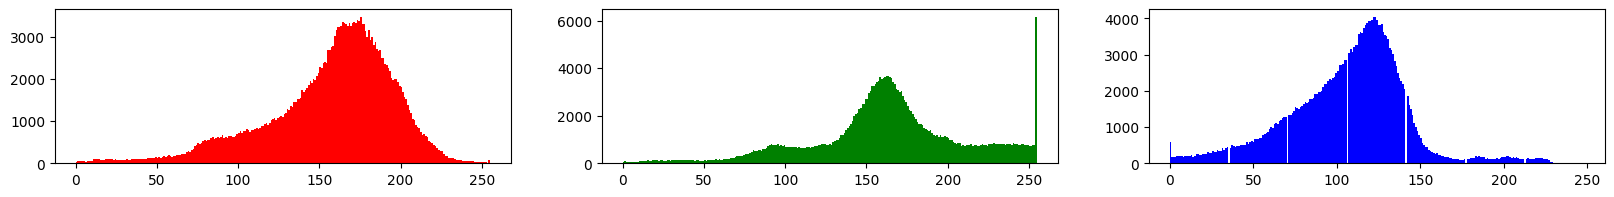

In [9]:
#히스토그램으로 나타내기
fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=255, color='r')
axs[1].hist(green_channel, bins=255, color='g')
axs[2].hist(blue_channel, bins=255, color='b')
plt.show()

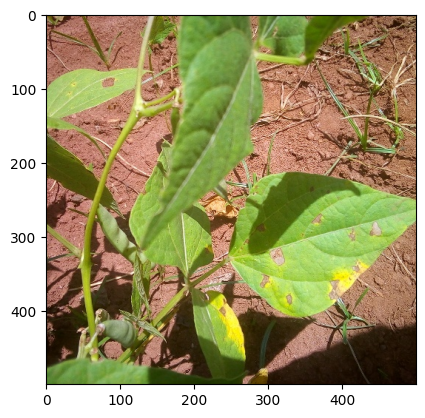

In [10]:
#다른 이미지
query_image = dataset[153]['image']
plt.imshow(query_image)
plt.show()

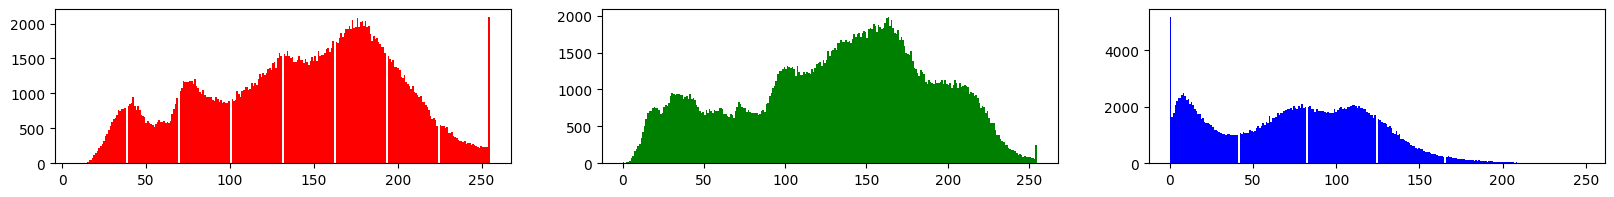

In [11]:
#동일하게 분포 나타내보기
query_image = np.array(query_image)
img_vector = query_image.reshape(1, -1, 3)

red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]

fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=255, color='r')
axs[1].hist(green_channel, bins=255, color='g')
axs[2].hist(blue_channel, bins=255, color='b')
plt.show()

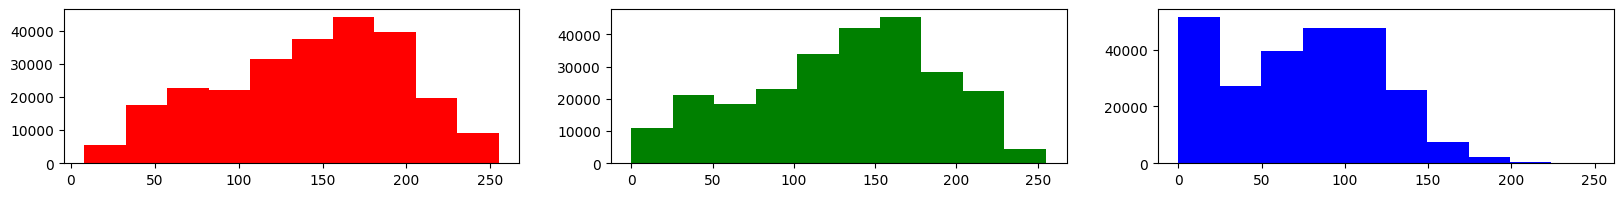

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=10, color='r')
axs[1].hist(green_channel, bins=10, color='g')
axs[2].hist(blue_channel, bins=10, color='b')
plt.show()

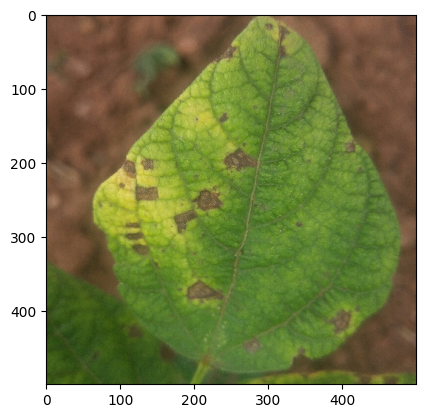

In [13]:
#마지막 이미지
query_image = dataset[141]['image']
plt.imshow(query_image)
plt.show()

컬러 히스토그램에 대해서 개념적인 부분들을 확인해봤으니까
- 개념적인 것들을 어떤식으로 이용해서, 유사한 이미지를 찾는지 본격적으로 다음시간에 다루겠음

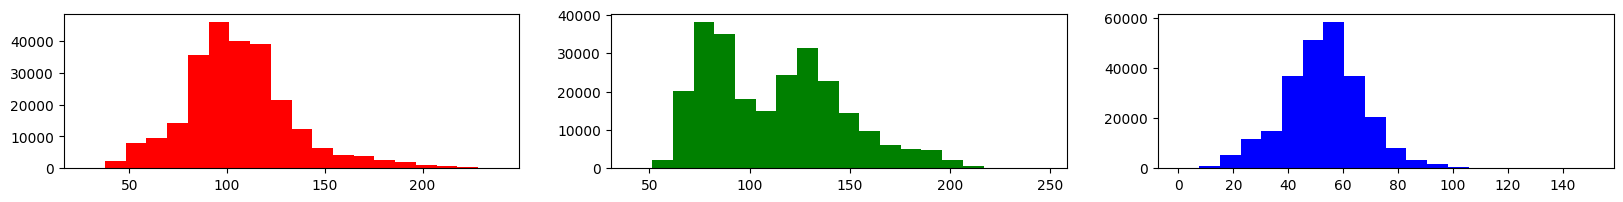

In [14]:
#마지막 이미지 분포 시각화
query_image = np.array(query_image)
img_vector = query_image.reshape(1, -1, 3)

red_channel = img_vector[0, :, 0]
green_channel = img_vector[0, :, 1]
blue_channel = img_vector[0, :, 2]

fig, axs = plt.subplots(1, 3, figsize=(20, 2))
axs[0].hist(red_channel, bins=20, color='r')
axs[1].hist(green_channel, bins=20, color='g')
axs[2].hist(blue_channel, bins=20, color='b')
plt.show()